# Deep Reinforcement Learning for Game Playing
### Deep Q-Network (DQN) Agent — CartPole-v1 (OpenAI Gym / Gymnasium)

**Author:** Maryam Saif
**Project Type:** Advanced — Deep Reinforcement Learning

This notebook trains a DQN agent from scratch to play **CartPole-v1**, a classic OpenAI Gym (Gymnasium) control task.
The same code can easily be adapted to Atari environments (e.g., `ALE/Pong-v5`, `ALE/Breakout-v5`) by changing the
environment name and adding a CNN-based feature extractor instead of the simple MLP used here.

### What this notebook covers
- Building a Deep Q-Network using PyTorch
- **Experience Replay** buffer
- **Epsilon-Greedy** exploration strategy (with decay)
- **Target Network** for stable Q-learning updates
- Training loop with reward tracking
- Visualization of reward curves over training episodes
- Saving the trained model and testing the agent


## 1. Install & Import Dependencies

In [1]:
!pip install gymnasium[classic_control] -q
!pip install torch -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 100.8 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import random
import math
from collections import deque, namedtuple
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Using device: cpu


## 2. Create the Environment

We use `CartPole-v1`: the agent must balance a pole on a moving cart by pushing left or right.

- **State space**: 4 continuous values (cart position, cart velocity, pole angle, pole angular velocity)
- **Action space**: 2 discrete actions (push left, push right)
- **Reward**: +1 for every timestep the pole stays balanced

> To switch to an Atari game, replace the env name with e.g. `ALE/Pong-v5` (requires `pip install gymnasium[atari,accept-rom-license]`)
and replace the MLP network below with a CNN that processes stacked grayscale frames.


In [3]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print(f"State dimension: {state_dim}")
print(f"Action dimension: {action_dim}")


State dimension: 4
Action dimension: 2


## 3. Experience Replay Buffer

Experience replay stores past transitions `(state, action, reward, next_state, done)` and samples random
mini-batches for training. This breaks the correlation between consecutive experiences and stabilizes learning.


In [4]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = torch.tensor(np.array([t.state for t in batch]), dtype=torch.float32, device=device)
        actions = torch.tensor([t.action for t in batch], dtype=torch.int64, device=device).unsqueeze(1)
        rewards = torch.tensor([t.reward for t in batch], dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array([t.next_state for t in batch]), dtype=torch.float32, device=device)
        dones = torch.tensor([t.done for t in batch], dtype=torch.float32, device=device).unsqueeze(1)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


## 4. Deep Q-Network Architecture

A simple fully-connected network that maps states to Q-values for each action.
For Atari, this would be a CNN (3 conv layers + 2 FC layers, as in the original DeepMind DQN paper).


In [5]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)


## 5. Epsilon-Greedy Exploration Strategy

The agent picks a random action with probability **epsilon** (exploration), and the best known action
otherwise (exploitation). Epsilon decays over time so the agent explores more early on and exploits
its learned policy more as training progresses.


In [6]:
EPS_START = 1.0
EPS_END = 0.02
EPS_DECAY = 5000  # higher = slower decay

def epsilon_by_step(step):
    return EPS_END + (EPS_START - EPS_END) * math.exp(-1.0 * step / EPS_DECAY)

def select_action(state, policy_net, step, action_dim):
    eps = epsilon_by_step(step)
    if random.random() < eps:
        return random.randrange(action_dim), eps
    else:
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = policy_net(state_t)
            return int(q_values.argmax(dim=1).item()), eps


## 6. Target Network & Optimization Step

The **target network** is a delayed copy of the policy network used to compute stable target Q-values.
It is updated periodically (every `TARGET_UPDATE` episodes), which prevents the "moving target" problem
that destabilizes training when the same network is used to both select and evaluate actions.


In [7]:
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-3

policy_net = DQN(state_dim, action_dim).to(device)
target_net = DQN(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
replay_buffer = ReplayBuffer(capacity=50000)

def optimize_model():
    if len(replay_buffer) < BATCH_SIZE:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

    # Current Q values for the actions taken
    q_values = policy_net(states).gather(1, actions)

    # Target Q values using the target network (Double DQN style max over next state)
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1, keepdim=True)[0]
        target_q = rewards + GAMMA * next_q_values * (1 - dones)

    loss = F.smooth_l1_loss(q_values, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10)
    optimizer.step()

    return loss.item()


## 7. Training Loop

We train for a fixed number of episodes, storing transitions in the replay buffer, optimizing the policy
network at every step, and periodically syncing the target network. We track the total reward per episode
to visualize learning progress.


In [8]:
NUM_EPISODES = 400
TARGET_UPDATE = 10  # episodes
SOLVE_THRESHOLD = 475  # CartPole-v1 is considered "solved" around here

episode_rewards = []
losses = []
global_step = 0

for episode in range(1, NUM_EPISODES + 1):
    state, _ = env.reset(seed=SEED + episode)
    total_reward = 0
    done = False

    while not done:
        action, eps = select_action(state, policy_net, global_step, action_dim)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, float(done))
        state = next_state
        total_reward += reward
        global_step += 1

        loss = optimize_model()
        if loss is not None:
            losses.append(loss)

    episode_rewards.append(total_reward)

    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % 20 == 0:
        avg_reward = np.mean(episode_rewards[-20:])
        print(f"Episode {episode:4d} | Avg Reward (last 20): {avg_reward:6.1f} | Epsilon: {eps:.3f}")

    # Early stop if solved
    if len(episode_rewards) >= 20 and np.mean(episode_rewards[-20:]) >= SOLVE_THRESHOLD:
        print(f"\nSolved at episode {episode}! Average reward over last 20 episodes: {np.mean(episode_rewards[-20:]):.1f}")
        break

env.close()


Episode   20 | Avg Reward (last 20):   21.0 | Epsilon: 0.921
Episode   40 | Avg Reward (last 20):   22.9 | Epsilon: 0.842
Episode   60 | Avg Reward (last 20):   28.6 | Epsilon: 0.753
Episode   80 | Avg Reward (last 20):   36.5 | Epsilon: 0.654
Episode  100 | Avg Reward (last 20):   50.8 | Epsilon: 0.537
Episode  120 | Avg Reward (last 20):   57.7 | Epsilon: 0.431
Episode  140 | Avg Reward (last 20):   97.8 | Epsilon: 0.298
Episode  160 | Avg Reward (last 20):   87.8 | Epsilon: 0.215
Episode  180 | Avg Reward (last 20):   69.5 | Epsilon: 0.168
Episode  200 | Avg Reward (last 20):  109.0 | Epsilon: 0.116
Episode  220 | Avg Reward (last 20):  135.0 | Epsilon: 0.076
Episode  240 | Avg Reward (last 20):  118.8 | Epsilon: 0.055
Episode  260 | Avg Reward (last 20):  137.8 | Epsilon: 0.040
Episode  280 | Avg Reward (last 20):  157.2 | Epsilon: 0.031
Episode  300 | Avg Reward (last 20):  370.2 | Epsilon: 0.022

Solved at episode 310! Average reward over last 20 episodes: 484.9


## 8. Reward Curve Visualization

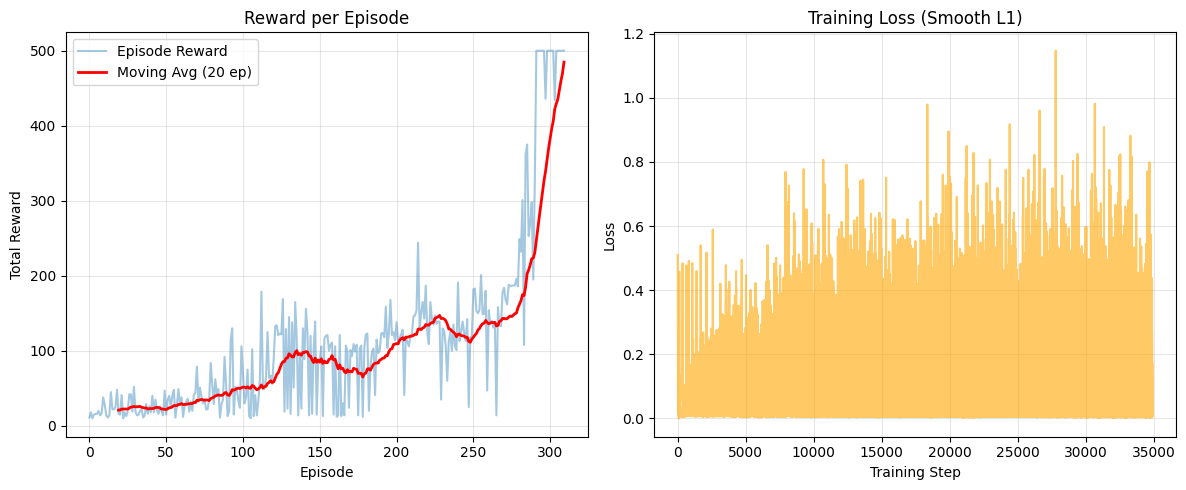

In [9]:
def moving_average(data, window=20):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode='valid')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(episode_rewards, alpha=0.4, label="Episode Reward")
if len(episode_rewards) >= 20:
    plt.plot(range(19, len(episode_rewards)), moving_average(episode_rewards, 20),
              color="red", linewidth=2, label="Moving Avg (20 ep)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward per Episode")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
if losses:
    plt.plot(losses, alpha=0.6, color="orange")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss (Smooth L1)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dqn_training_curves.png", dpi=150)
plt.show()


## 9. Evaluate the Trained Agent

Run the trained policy greedily (no exploration) for a few episodes to see how well it performs.


In [10]:
def evaluate(policy_net, env_name="CartPole-v1", episodes=5, render=False):
    eval_env = gym.make(env_name, render_mode="human" if render else None)
    rewards = []

    for ep in range(episodes):
        state, _ = eval_env.reset()
        total_reward = 0
        done = False
        while not done:
            with torch.no_grad():
                state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(policy_net(state_t).argmax(dim=1).item())
            state, reward, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            total_reward += reward
        rewards.append(total_reward)
        print(f"Eval Episode {ep+1}: Reward = {total_reward}")

    eval_env.close()
    print(f"\nAverage evaluation reward: {np.mean(rewards):.1f}")
    return rewards

# Note: set render=True only on a local machine with a display; not supported in Colab without extra setup
eval_rewards = evaluate(policy_net, episodes=5, render=False)


Eval Episode 1: Reward = 235.0
Eval Episode 2: Reward = 227.0
Eval Episode 3: Reward = 244.0
Eval Episode 4: Reward = 234.0
Eval Episode 5: Reward = 239.0

Average evaluation reward: 235.8


## 10. Save the Trained Model

In [11]:
torch.save(policy_net.state_dict(), "dqn_cartpole.pth")
print("Model saved as dqn_cartpole.pth")


Model saved as dqn_cartpole.pth


## 11. Extending This Project to Atari Games

To adapt this notebook for Atari (e.g., Pong, Breakout):

1. **Install Atari extras**:
   `!pip install gymnasium[atari,accept-rom-license] -q`
2. **Environment**: use `gym.make("ALE/Pong-v5")` and wrap with preprocessing:
   - Grayscale conversion
   - Frame resizing (84x84)
   - Frame stacking (4 frames) to capture motion
   - Use `gymnasium.wrappers.AtariPreprocessing` and `FrameStackObservation`
3. **Network**: replace the MLP in `DQN` with a CNN:
   - 3 convolutional layers (as in the original Nature DQN paper: 32 filters 8x8 stride 4, 64 filters 4x4 stride 2, 64 filters 3x3 stride 1)
   - Followed by 2 fully connected layers
4. **Training**: Atari typically needs millions of steps and a much larger replay buffer (e.g., 1M), so training is best done on a GPU runtime with checkpointing.

The core DQN logic (replay buffer, epsilon-greedy, target network, optimization step) stays exactly the same —
only the input preprocessing and network architecture change.


## Summary

This notebook implemented a complete Deep Q-Network agent including:
- A neural network Q-function approximator
- Experience replay for stable, decorrelated training
- Epsilon-greedy exploration with decay
- A target network to stabilize Q-value targets
- Full training loop with reward/loss tracking and visualization
- Model evaluation and saving

This forms the foundation for more advanced Deep RL algorithms such as **Double DQN**, **Dueling DQN**,
**Prioritized Experience Replay**, and **Rainbow DQN**.
